In [1]:
# Importing relevant packages
import warnings # Suppresses noisy FutureWarnings from pandas/seaborn

import matplotlib.pyplot as plt # Core plotting library
import numpy as np # Numerical computation
import pandas as pd # Data manipulation
import seaborn as sns # Statistical visualisation built on matplotlib

warnings.simplefilter(action="ignore", category=FutureWarning)

In [2]:
# load datasets
titanic_df = pd.read_csv("Titanic-Dataset.csv")
titanic_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
# Making an original copy of the data 

titanic_copy = titanic_df.copy()

In [4]:
# Inspect all column names to understand the available features

titanic_df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [5]:
# Summary statistics for all numeric columns

titanic_df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


### Dealing with missing values

In [6]:
# Identify the number of missing values
titanic_df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [7]:
# Express missing values as a percentage of total rows.
round(titanic_df.isna().mean() * 100, 2)

PassengerId     0.00
Survived        0.00
Pclass          0.00
Name            0.00
Sex             0.00
Age            19.87
SibSp           0.00
Parch           0.00
Ticket          0.00
Fare            0.00
Cabin          77.10
Embarked        0.22
dtype: float64

- There are 19.87% of missed values in 'Age' column
- There are 77.10% of missed values in 'Cabin' column
- There are 0.22% of missed values in 'Embarked' column

In [8]:
# Fill missing ages with median
# The median is preferred because Age has a right-skewed distribution
titanic_df["Age"].fillna(titanic_df["Age"].median(), inplace=True)

# Drop rows with missing Embarked
# Dropping them has negligible impact.
titanic_df.dropna(subset=["Embarked"], inplace=True)

# Drop Cabin Column
titanic_df.drop(columns='Cabin', inplace=True)

In [9]:
# Handling duplicate rows

duplucate = titanic_df.duplicated().sum()

print(f'There are {duplucate} duplicated rows')

There are 0 duplicated rows


### Adding a new column

In [10]:
# Adding a new column 'family_size'
# A single or larger family size may affect survival odds

titanic_df['family_size'] = titanic_df['SibSp'] + titanic_df['Parch'] + 1

titanic_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,family_size
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,2
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,2
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,2
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,1


### EDA and Visualization

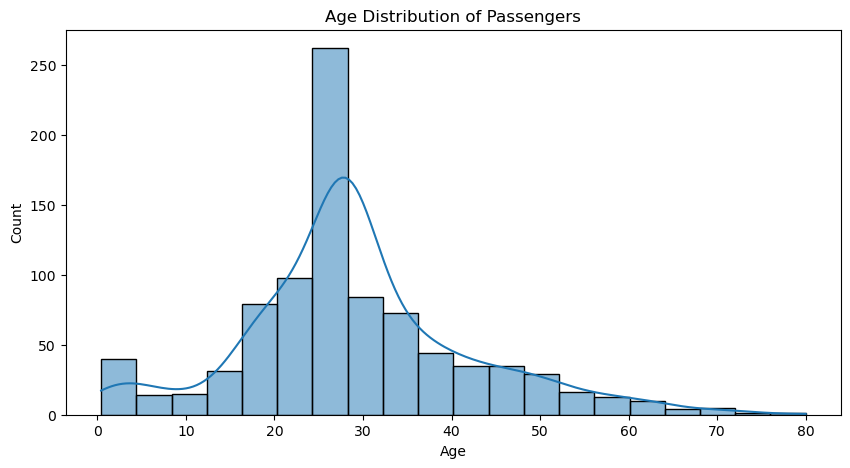

In [11]:
# Age distribution
plt.figure(figsize=(10, 5))
sns.histplot(titanic_df["Age"], bins=20, kde=True)
plt.title('Age Distribution of Passengers', fontsize=12)
plt.show()

In [12]:
# Number of survived passenger

titanic_df['Survived'].value_counts()

Survived
0    549
1    340
Name: count, dtype: int64

In [13]:
# Number of males and females

titanic_df['Sex'].value_counts()

Sex
male      577
female    312
Name: count, dtype: int64

In [14]:
# Number of passengers by class

titanic_df["Pclass"].value_counts().sort_index()

Pclass
1    214
2    184
3    491
Name: count, dtype: int64

In [15]:
# Survival rate by gender

gender_survival = titanic_df.groupby("Sex")["Survived"].mean() * 100
gender_survival.round(2)

Sex
female    74.04
male      18.89
Name: Survived, dtype: float64

In [16]:
# Average fare by passenger class

titanic_df.groupby('Pclass')['Fare'].mean()

Pclass
1    84.193516
2    20.662183
3    13.675550
Name: Fare, dtype: float64

In [17]:
# How passenger class affected suevival 

class_survival = titanic_df.groupby("Pclass")["Survived"].mean() * 100
class_survival.round(1)

Pclass
1    62.6
2    47.3
3    24.2
Name: Survived, dtype: float64

In [18]:
# Survival by blass and Sex 
class_sex_survival = titanic_df.groupby(['Sex', 'Pclass'])['Survived'].mean() * 100
class_sex_survival

Sex     Pclass
female  1         96.739130
        2         92.105263
        3         50.000000
male    1         36.885246
        2         15.740741
        3         13.544669
Name: Survived, dtype: float64

In [19]:
# Average age of survivors and non survivors

survival_age = titanic_df.groupby("Survived")["Age"].mean()
survival_age

Survived
0    30.028233
1    28.163735
Name: Age, dtype: float64

In [20]:
# How fare affected ssurvival
fare_by_survival = titanic_df.groupby("Survived")["Fare"].mean()
fare_by_survival

Survived
0    22.117887
1    48.209498
Name: Fare, dtype: float64

In [21]:
# percentage of surviivors who travelled alone VS with family

titanic_df['family_group'] = titanic_df['family_size'].apply(lambda x: 'Alone' if x == 1 else 'With Family')
family_group_by_survival = titanic_df.groupby('family_group')['Survived'].mean() * 100
family_group_by_survival

family_group
Alone          30.093458
With Family    50.564972
Name: Survived, dtype: float64

In [22]:
# Family group by survival 

family_group_survival = titanic_df.groupby("family_group")["Survived"].mean()*100
family_group_survival

family_group
Alone          30.093458
With Family    50.564972
Name: Survived, dtype: float64

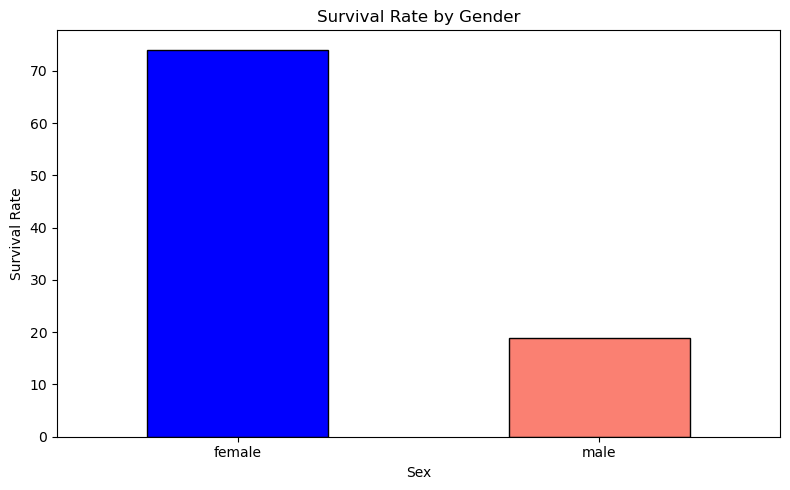

In [23]:
# Survival by Gender

plt.figure(figsize = (8, 5))
gender_survival.plot(kind="bar", color=["blue", "salmon"], edgecolor = "black")
plt.title("Survival Rate by Gender")
plt.ylabel("Survival Rate")
plt.xticks(rotation = 0)
plt.tight_layout()
plt.show()

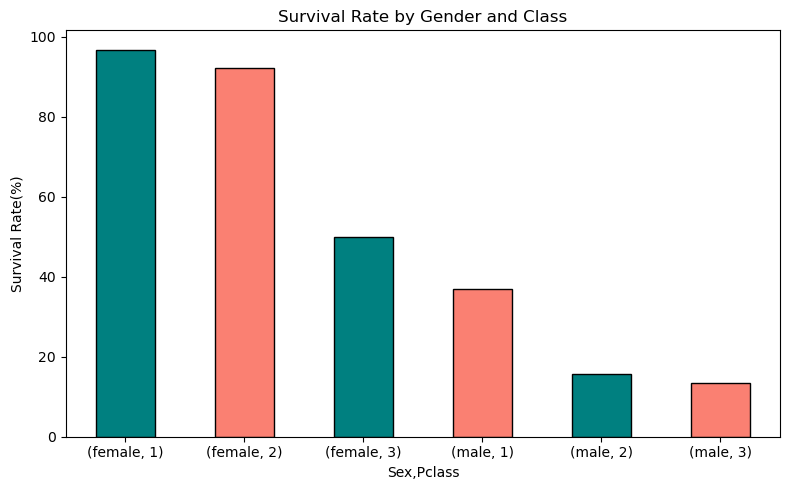

In [24]:
# Survival rate by Class and Gender

plt.figure(figsize = (8, 5))
class_sex_survival.plot(kind="bar", color=["teal", "salmon"], edgecolor = "black")
plt.title("Survival Rate by Gender and Class")
plt.ylabel("Survival Rate(%)")
plt.xticks(rotation = 0)
plt.tight_layout()
plt.show()

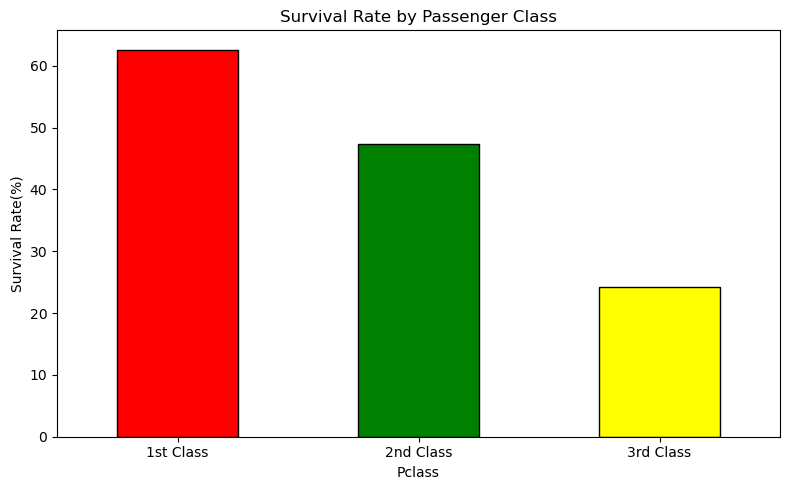

In [25]:
# Survival by class
plt.figure(figsize = (8, 5))
class_survival.plot(kind = "bar", color = ["red", "green", "yellow"], edgecolor = "black")
plt.title("Survival Rate by Passenger Class")
plt.ylabel("Survival Rate(%)")
plt.xticks([0, 1, 2], ["1st Class", "2nd Class", "3rd Class"], rotation = 0)
plt.tight_layout()
plt.show()

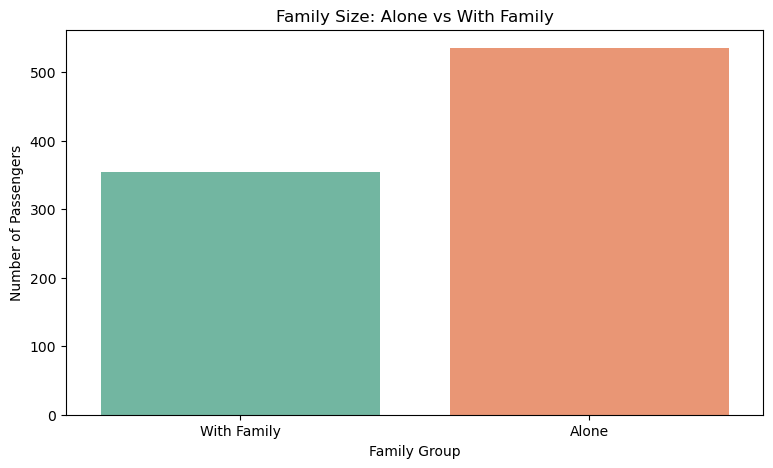

In [26]:
# Family group onboard 
plt.figure(figsize = (9, 5))
sns.countplot(x='family_group', data=titanic_df, palette='Set2')
plt.title('Family Size: Alone vs With Family')
plt.xlabel('Family Group')
plt.ylabel('Number of Passengers')
plt.show()

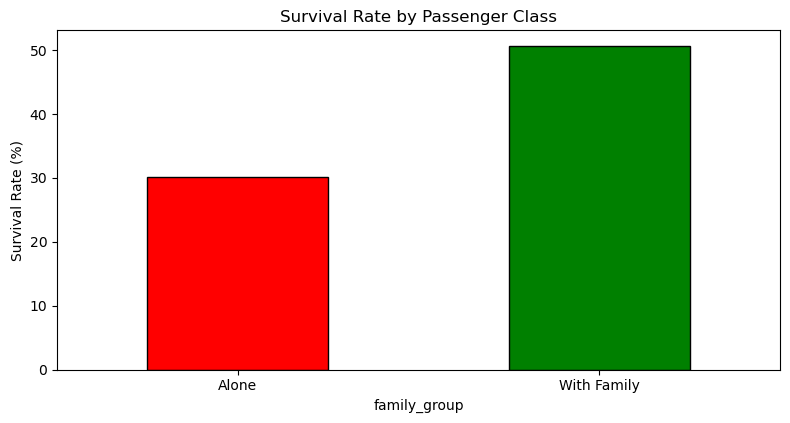

In [27]:
# Survival rate by Family group 
plt.figure(figsize = (8, 5))
family_group_survival.plot(kind = "bar", color = ["red", "green", "yellow"], edgecolor = "black")
plt.title("Survival Rate by Passenger Class")
plt.ylabel("Survival Rate (%)")
plt.tight_layout()
plt.xticks(rotation=0)
plt.show()

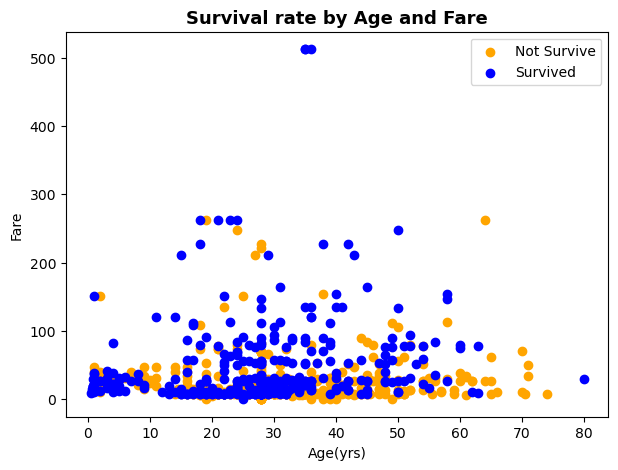

In [28]:
# Age vs Sex with Survived 

survived = titanic_df[titanic_df['Survived'] == 1]
not_survived = titanic_df[titanic_df['Survived'] == 0]

plt.figure(figsize = (7, 5))
plt.scatter(not_survived["Age"], not_survived["Fare"], color = "orange", label = "Not Survive")
plt.scatter(survived["Age"], survived["Fare"], color = "blue", label = "Survived")
plt.title("Survival rate by Age and Fare", fontsize = 13, fontweight = "bold")
plt.xlabel("Age(yrs)")
plt.ylabel("Fare")
plt.legend()
plt.show()

In [29]:
titanic_df.to_csv("titanic_cleaned.csv", index=False)

## Conclusions

1. Female passengers had a survival rate than males. We can suggest that the 'women and children first' evacuation protocol was rigorously followed.

2. 1st class Passengers had higher survival rate. We can suggest they had better physical access to lifeboats and may have received preferential treatment.

3.  A 3rd-class woman ⁓50% survival had a higher chance of survival than a 1st-class man ⁓37%. Gender was an overriding factor of survival rather than class.

4.  Survivors paid higher fares on average than non-survivors. Since fare directly maps to passenger class, this reinforces finding #2.

5.  Passengers with family had a ~50% survival rate, compared to ~30% for solo travellers. Families, especially those with young children, may have been prioritised at lifeboats.

6. Survivors were only marginally younger on average ⁓28 years than non-survivors ⁓30 years
